In [1]:
'''
Ваша задача — построить скоринговую модель (IRB-подход согласно Базельским стандартам), 
которая предсказывает Probability of Default (PD) — вероятность того, что клиент 
допустит просрочку более 90 дней (NPL 90+) в течение следующего года.

Вам предстоит решить три классические банковские проблемы:

Разрозненность данных (Data Silos): Данные не лежат в одном файле. 
У вас есть анкета клиента, его кредитная история в других банках (из БКИ) и история его 
прошлых обращений в ваш банк. Их нужно правильно агрегировать и свести (JOIN).
Дисбаланс классов: Дефолтников всегда мало (около 8%). Алгоритм нужно заставить обращать на них внимание.
Объяснимость (Explainability): Модель не может быть "черным ящиком". Отказ в кредите 
должен быть аргументирован (согласно требованиям ЦБ). Мы будем использовать аппарат SHAP.
Источник данных:
Мы используем соревнование Kaggle: "Home Credit Default Risk".
Ссылка на скачивание:https://www.kaggle.com/c/home-credit-default-risk/data
https://disk.yandex.ru/d/HFRhiHgfRqbSPw
''

_IncompleteInputError: incomplete input (3857640367.py, line 1)

In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# TODO 1.1: Загрузите три датасета с помощью pd.read_csv()
app_data = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')
prev_app = pd.read_csv('previous_application.csv')

print(f"Размер таблицы заявок: {app_data.shape}")
print(f"Размер таблицы БКИ: {bureau.shape}")
print(f"Размер таблицы прошлых заявок: {prev_app.shape}")
app_data.head()
# TODO 1.2: Оцените дисбаланс классов в app_data.
# Выведите долю (в процентах) дефолтных (TARGET=1) и надежных (TARGET=0) клиентов.
# Используйте метод value_counts(normalize=True).
class_balance = app_data[app_data['TARGET']==1]['TARGET'].count() / app_data['TARGET'].count()
print(f"\nДисбаланс классов:\n{class_balance * 100}")


Размер таблицы заявок: (307511, 122)
Размер таблицы БКИ: (1716428, 17)
Размер таблицы прошлых заявок: (1670214, 37)

Дисбаланс классов:
8.072881945686495


In [33]:
app_data.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
bureau[bureau['SK_ID_CURR'] == 100001]['AMT_CREDIT_MAX_OVERDUE']

248484   NaN
248485   NaN
248486   NaN
248487   NaN
248488   NaN
248489   NaN
248490   NaN
Name: AMT_CREDIT_MAX_OVERDUE, dtype: float64

In [31]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': ['count'],
    'AMT_CREDIT_SUM': 'sum',
    'AMT_CREDIT_MAX_OVERDUE': 'max'
})
print(bureau_agg.columns)
bureau_agg.columns =['BUREAU_LOANS_COUNT', 'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_OVERDUE']
bureau_agg.head()

MultiIndex([(          'SK_ID_BUREAU', 'count'),
            (        'AMT_CREDIT_SUM',   'sum'),
            ('AMT_CREDIT_MAX_OVERDUE',   'max')],
           )


,BUREAU_LOANS_COUNT,BUREAU_TOTAL_DEBT,BUREAU_MAX_OVERDUE
SK_ID_CURR,,,
100001,7,1453365.000,NaN
100002,8,865055.565,5043.645
100003,4,1017400.500,0.000
100004,2,189037.800,0.000
100005,3,657126.000,0.000


In [39]:
# TODO 2.1: Агрегация данных БКИ (bureau).
# Сгруппируйте данные по клиенту ('SK_ID_CURR'). 
# Рассчитайте:
# 1. Количество кредитов в других банках (count по колонке 'SK_ID_BUREAU')
# 2. Суммарный текущий долг (sum по 'AMT_CREDIT_SUM')
# 3. Максимальную просрочку (max по 'AMT_CREDIT_MAX_OVERDUE')
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',
    'AMT_CREDIT_SUM': 'sum',
    'AMT_CREDIT_MAX_OVERDUE': 'max'
})
bureau_agg.columns =['BUREAU_LOANS_COUNT', 'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_OVERDUE']
bureau_agg.reset_index(inplace=True)

# TODO 2.2: Агрегация внутренних данных банка (prev_app).
# Сгруппируйте по 'SK_ID_CURR'.
# Рассчитайте:
# 1. Количество прошлых заявок (count по 'SK_ID_PREV')
# 2. Среднюю запрошенную сумму (mean по 'AMT_APPLICATION')
prev_agg = prev_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_APPLICATION': 'mean'
})
prev_agg.columns =['PREV_APPS_COUNT', 'PREV_AVG_AMT_REQUESTED']
prev_agg.reset_index(inplace=True)

# TODO 2.3: Сведение витрины данных (Data Mart).
# Присоедините к app_data сначала bureau_agg, затем prev_agg.
# Используйте pd.merge() с параметром how='left', ключом выступает 'SK_ID_CURR'.
full_df = app_data.merge(bureau_agg, how='left', on='SK_ID_CURR')
full_df = full_df.merge(prev_agg, how='left', on='SK_ID_CURR')

# Заполняем образовавшиеся пропуски нулями (если нет истории, значит 0 кредитов)
cols_to_fill =['BUREAU_LOANS_COUNT', 'BUREAU_TOTAL_DEBT', 'BUREAU_MAX_OVERDUE', 'PREV_APPS_COUNT', 'PREV_AVG_AMT_REQUESTED']
full_df[cols_to_fill] = full_df[cols_to_fill].fillna(0)

print(f"Размер итоговой витрины: {full_df.shape}")


Размер итоговой витрины: (307511, 127)


In [41]:
full_df['ATI_RATIO'] = full_df['AMT_ANNUITY'] / full_df['AMT_INCOME_TOTAL']
full_df['ATI_RATIO'].count()

np.int64(307499)

In [42]:
# TODO 3.1: Рассчитайте Debt-to-Income (DTI).
# Отношение суммы кредита (AMT_CREDIT) к доходу клиента (AMT_INCOME_TOTAL).
full_df['DTI_RATIO'] = full_df['AMT_CREDIT'] / full_df['AMT_INCOME_TOTAL']

# TODO 3.2: Рассчитайте Annuity-to-Income (ATI).
# Отношение ежемесячного платежа (AMT_ANNUITY) к доходу (AMT_INCOME_TOTAL).
# Это главный показатель долговой нагрузки (ПДН).
full_df['ATI_RATIO'] = full_df['AMT_ANNUITY'] / full_df['AMT_INCOME_TOTAL']

# Убираем ID клиента (алгоритму он не нужен, только навредит)
full_df.drop(columns=['SK_ID_CURR'], inplace=True)


In [50]:
full_df.head(20)

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_LOANS_COUNT,BUREAU_TOTAL_DEBT,BUREAU_MAX_OVERDUE,PREV_APPS_COUNT,PREV_AVG_AMT_REQUESTED,ATI_RATIO,DTI_RATIO
0,1,Cash loans,M,N,Y,0,202500.000,406597.5,24700.5,351000.0,...,0.0,0.0,1.0,8.0,865055.565,5043.645,1.0,179055.000000,0.121978,2.007889
1,0,Cash loans,F,N,N,0,270000.000,1293502.5,35698.5,1129500.0,...,0.0,0.0,0.0,4.0,1017400.500,0.000,3.0,435436.500000,0.132217,4.790750
2,0,Revolving loans,M,Y,Y,0,67500.000,135000.0,6750.0,135000.0,...,0.0,0.0,0.0,2.0,189037.800,0.000,1.0,24282.000000,0.100000,2.000000
3,0,Cash loans,F,N,Y,0,135000.000,312682.5,29686.5,297000.0,...,NaN,NaN,NaN,0.0,0.000,0.000,9.0,272203.260000,0.219900,2.316167
4,0,Cash loans,M,N,Y,0,121500.000,513000.0,21865.5,513000.0,...,0.0,0.0,0.0,1.0,146250.000,0.000,6.0,150530.250000,0.179963,4.222222
5,0,Cash loans,M,N,Y,0,99000.000,490495.5,27517.5,454500.0,...,0.0,1.0,1.0,3.0,468445.500,0.000,5.0,155701.800000,0.277955,4.954500
6,0,Cash loans,F,Y,Y,1,171000.000,1560726.0,41301.0,1395000.0,...,1.0,1.0,2.0,18.0,4800811.500,0.000,7.0,76741.714286,0.241526,9.127053
7,0,Cash loans,M,Y,Y,0,360000.000,1530000.0,42075.0,1530000.0,...,0.0,0.0,0.0,2.0,990000.000,0.000,1.0,247212.000000,0.116875,4.250000
8,0,Cash loans,F,N,Y,0,112500.000,1019610.0,33826.5,913500.0,...,0.0,0.0,1.0,4.0,435228.300,10147.230,4.0,202732.875000,0.300680,9.063200
9,0,Revolving loans,M,N,Y,0,135000.000,405000.0,20250.0,405000.0,...,NaN,NaN,NaN,0.0,0.000,0.000,4.0,60930.000000,0.150000,3.000000


In [54]:
from sklearn.model_selection import train_test_split

y = full_df['TARGET']
X = full_df.drop(columns=['TARGET'])

# TODO 4.1: Разделите выборку на Train и Test (80/20).
# ВАЖНО: добавьте параметр stratify=y, чтобы сохранить пропорцию дефолтов.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y)

# Подготовка категориальных признаков для CatBoost
# CatBoost требует, чтобы пустые текстовые ячейки были чем-то заполнены.
cat_features = np.where(X.dtypes == object)[0].tolist()

X_train.iloc[:, cat_features] = X_train.iloc[:, cat_features].fillna('Missing_Category')
X_test.iloc[:, cat_features] = X_test.iloc[:, cat_features].fillna('Missing_Category')


In [56]:
y_train.sum()/y_train.count()

np.float64(0.08072908198107379)

In [58]:
from catboost import CatBoostClassifier

# TODO 5.1: Инициализируйте модель CatBoost.
# Решение проблемы дисбаланса: задайте auto_class_weights='Balanced'.
# Количество итераций (деревьев): 300, random_seed=42.
model = CatBoostClassifier(iterations=300)

print("Запуск обучения модели (может занять 1-2 минуты)...")
# TODO 5.2: Обучите модель (fit), обязательно передав список cat_features.
model.fit(X_train, y_train, cat_features=cat_features)

# TODO 5.3: Получите предсказания вероятности дефолта (Probability of Default) для X_test.
# Используйте метод predict_proba(). Нам нужен только второй столбец [:, 1] (вероятность единицы).
# y_pred_proba = # <ВАШ_КОД>


Запуск обучения модели (может занять 1-2 минуты)...
Learning rate set to 0.326099
0:	learn: 0.4198848	total: 134ms	remaining: 40.1s
1:	learn: 0.3303366	total: 221ms	remaining: 32.9s
2:	learn: 0.2918620	total: 311ms	remaining: 30.8s
3:	learn: 0.2718974	total: 374ms	remaining: 27.7s
4:	learn: 0.2625035	total: 450ms	remaining: 26.5s
5:	learn: 0.2583380	total: 524ms	remaining: 25.7s
6:	learn: 0.2563994	total: 603ms	remaining: 25.2s
7:	learn: 0.2545160	total: 686ms	remaining: 25s
8:	learn: 0.2530421	total: 770ms	remaining: 24.9s
9:	learn: 0.2520268	total: 842ms	remaining: 24.4s
10:	learn: 0.2514687	total: 939ms	remaining: 24.7s
11:	learn: 0.2506157	total: 1.01s	remaining: 24.2s
12:	learn: 0.2500291	total: 1.08s	remaining: 23.8s
13:	learn: 0.2495615	total: 1.16s	remaining: 23.7s
14:	learn: 0.2492594	total: 1.25s	remaining: 23.7s
15:	learn: 0.2487182	total: 1.32s	remaining: 23.4s
16:	learn: 0.2484942	total: 1.4s	remaining: 23.3s
17:	learn: 0.2481325	total: 1.48s	remaining: 23.2s
18:	learn: 0.

In [59]:
y_pred_proba = model.predict_proba(X_test)

In [96]:
np.concatenate([np.array([1,2,3]), np.array([4,5,6])])

array([1, 2, 3, 4, 5, 6])

In [97]:
idx = np.concatenate([np.where(y_test.values==1)[0], np.where(y_test.values==0)[0][:4965]])
X_test_2 = X_test.iloc[idx]
y_test_2 = y_test.iloc[idx]

ROC-AUC: 0.7574
Коэффициент Джини: 0.5147


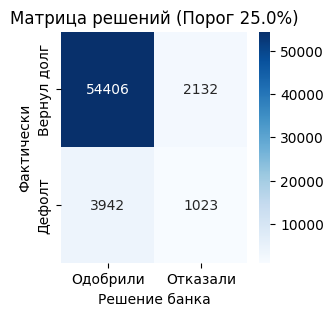

In [80]:
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy
import seaborn as sns
import matplotlib.pyplot as plt

# TODO 6.1: Рассчитайте ROC-AUC
y_pred_proba = model.predict_proba(X_test)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# TODO 6.2: Рассчитайте коэффициент Джини (Gini = 2 * AUC - 1). 
# Это стандартная метрика Банка России.
gini = 2 * auc - 1

print(f"ROC-AUC: {auc:.4f}")
print(f"Коэффициент Джини: {gini:.4f}")

# # TODO 6.3: Принятие бизнес-решения (Порог отсечения).
# # Банк решает: "Если PD > 15%, мы отказываем в кредите".
# # Создайте массив предсказаний классов (1 - дефолт, 0 - выплата), где 1 ставится, если y_pred_proba > 0.15.
# # Используйте np.where().
threshold = 0.25
y_pred_business = np.where(y_pred_proba[:, 1] > threshold, 1, 0)

# # Строим матрицу ошибок (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_business)

# # Визуализация матрицы ошибок (код готов для экономии времени)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Одобрили', 'Отказали'], 
            yticklabels=['Вернул долг', 'Дефолт'])
plt.ylabel('Фактически')
plt.xlabel('Решение банка')
plt.title(f'Матрица решений (Порог {threshold*100}%)')
plt.show()



ROC-AUC: 0.7569
Коэффициент Джини: 0.5138


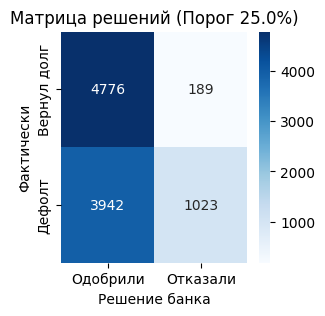

In [98]:

# TODO 6.1: Рассчитайте ROC-AUC
y_pred_proba_2 = model.predict_proba(X_test_2)
auc = roc_auc_score(y_test_2, y_pred_proba_2[:, 1])

# TODO 6.2: Рассчитайте коэффициент Джини (Gini = 2 * AUC - 1). 
# Это стандартная метрика Банка России.
gini = 2 * auc - 1

print(f"ROC-AUC: {auc:.4f}")
print(f"Коэффициент Джини: {gini:.4f}")

# # TODO 6.3: Принятие бизнес-решения (Порог отсечения).
# # Банк решает: "Если PD > 15%, мы отказываем в кредите".
# # Создайте массив предсказаний классов (1 - дефолт, 0 - выплата), где 1 ставится, если y_pred_proba > 0.15.
# # Используйте np.where().
threshold = 0.25
y_pred_business_2 = np.where(y_pred_proba_2[:, 1] > threshold, 1, 0)

# # Строим матрицу ошибок (Confusion Matrix)
cm = confusion_matrix(y_test_2, y_pred_business_2)

# # Визуализация матрицы ошибок (код готов для экономии времени)
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Одобрили', 'Отказали'], 
            yticklabels=['Вернул долг', 'Дефолт'])
plt.ylabel('Фактически')
plt.xlabel('Решение банка')
plt.title(f'Матрица решений (Порог {threshold*100}%)')
plt.show()

In [76]:
threshold = 0.15
y_pred_business = np.where(y_pred_proba[:, 1] > threshold, 1, 0)
y_pred_business

array([1, 0, 0, ..., 0, 0, 0], shape=(61503,))

In [107]:
y_pred_proba_3 = np.random.randint(0, 2, len(y_pred_proba))
y_pred_proba_4 = np.random.randint(0, 2, len(y_pred_proba_2))

np.float64(0.4988211957140302)

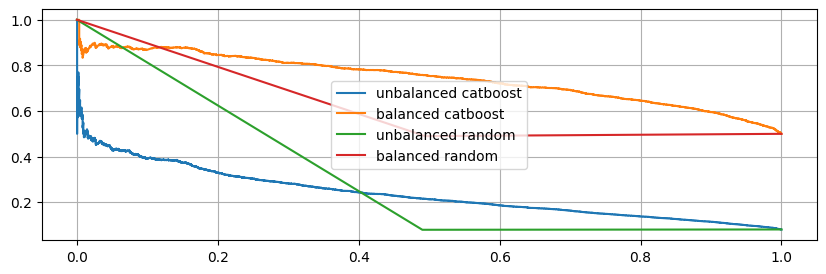

In [105]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba[:, 1])
precision_2, recall_2, thresholds_2 = precision_recall_curve(y_test_2, y_pred_proba_2[:, 1])
precision_3, recall_3, thresholds_3 = precision_recall_curve(y_test, y_pred_proba_3)
precision_4, recall_4, thresholds_4 = precision_recall_curve(y_test_2, y_pred_proba_4)
plt.figure(figsize=(10, 3))
plt.plot(recall, precision, label='unbalanced catboost')
plt.plot(recall_2, precision_2,  label='balanced catboost')
plt.plot(recall_3, precision_3, label='unbalanced random')
plt.plot(recall_4, precision_4,  label='balanced random')
plt.legend()
plt.grid()

In [111]:
import shap

Подготовка SHAP Explainer...
Глобальная важность признаков:


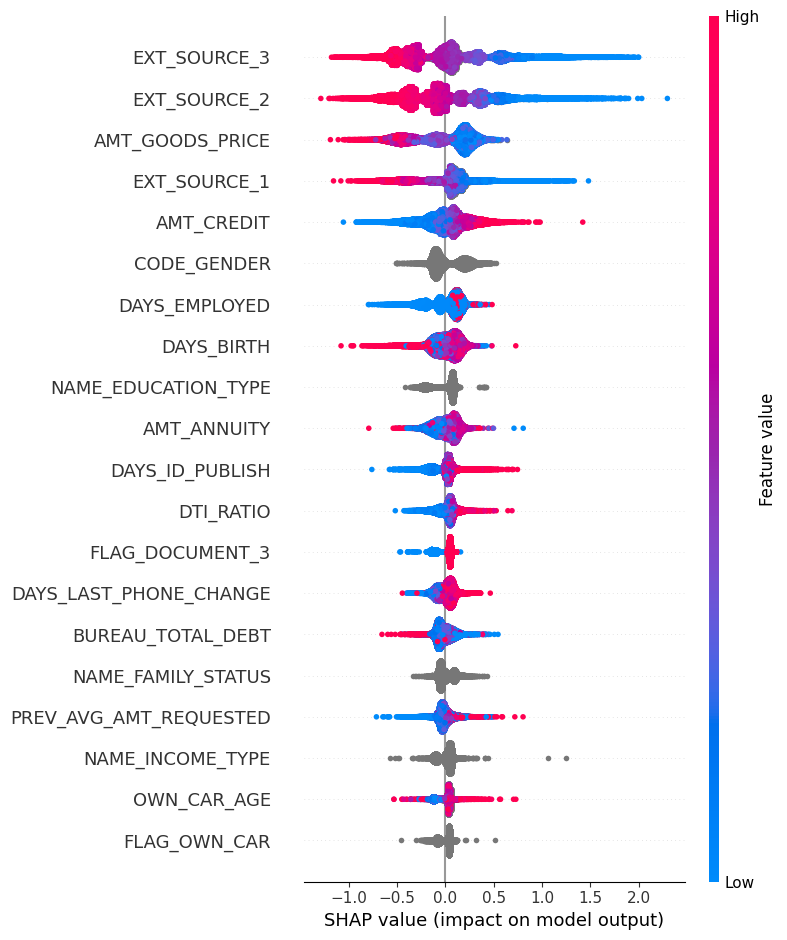


Анализ клиента № 283. Вероятность дефолта (PD): 64.97%


TypeError: force() missing 1 required positional argument: 'base_value'

In [113]:
import shap

print("Подготовка SHAP Explainer...")
# TODO 7.1: Инициализируйте shap.TreeExplainer, передав в него обученную модель.
explainer = shap.TreeExplainer(model)

# Берем 500 случайных клиентов для скорости расчетов
X_sample = X_test.sample(500, random_state=42)

# TODO 7.2: Рассчитайте SHAP-значения для выборки.
shap_values = explainer.shap_values(X_test, y_test)

# 1. Глобальная важность факторов (Что драйвит риск портфеля?)
print("Глобальная важность признаков:")
shap.summary_plot(shap_values, X_test)

# 2. Локальное объяснение (Печатаем причину отказа)
# Найдем клиента с самым высоким риском в выборке
client_idx = np.argmax(model.predict_proba(X_sample)[:, 1])
client_pd = model.predict_proba(X_sample)[client_idx, 1]

print(f"\nАнализ клиента № {client_idx}. Вероятность дефолта (PD): {client_pd:.2%}")

# Обязательно инициализируем JS для отрисовки
shap.initjs()

# TODO 7.3: Вызовите shap.force_plot() для конкретного клиента.
# Аргументы: 
# 1. Базовое значение: explainer.expected_value
# 2. Вектор SHAP-значений для клиента: shap_values[client_idx]
# 3. Данные клиента: X_sample.iloc[client_idx]
shap.force_plot(
    # <ВАШ_КОД>,
    # <ВАШ_КОД>,
    # <ВАШ_КОД>
)


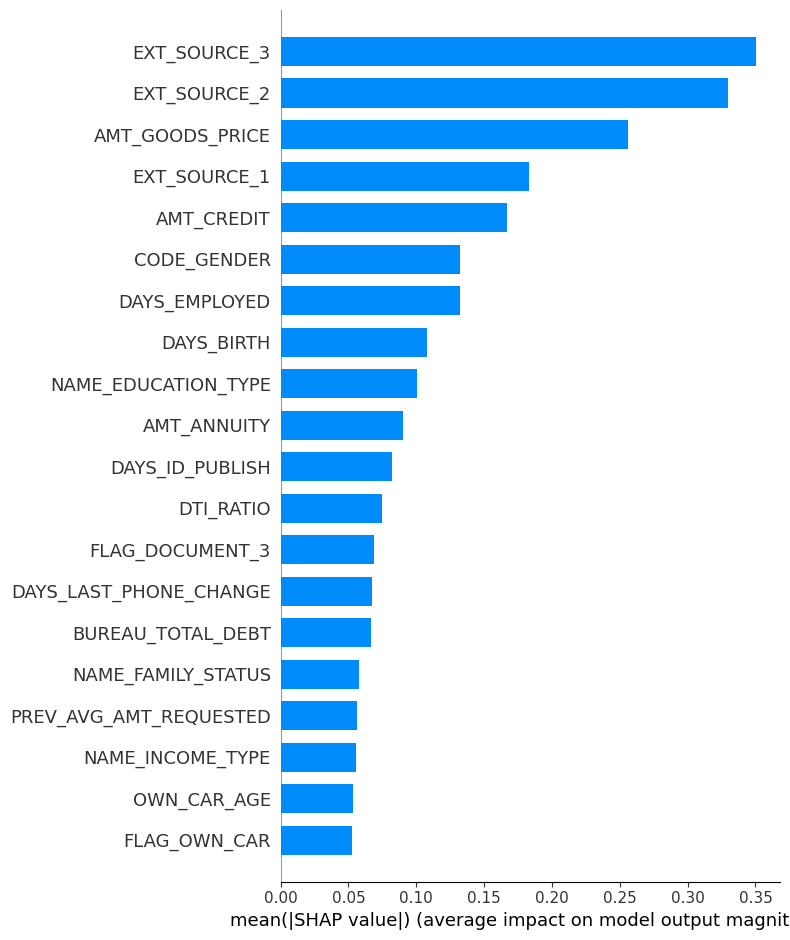

In [114]:
shap.summary_plot(shap_values, X_test, plot_type='bar')